# Part 7 — Reward Modeling: A Walkthrough

## Think of it as training a judge who learns your taste 🧑‍⚖️

Before any code, here's the one picture that explains this entire notebook. Keep it in your head the whole way through:

> After Part 6 the new hire writes *one* correct answer — the single gold reply we handed it. But "good" is rarely a single right answer. Ask two people to summarize a paper and you get two different good summaries, plus a silly one like *"Scaling laws are when you scale pictures to look bigger."* You can't easily score any one answer out of 100 — but you **can** reliably say *"this one is better than that one."*
>
> **Part 7 trains a judge.** We show it *pairs* — a **chosen** answer and a **rejected** answer to the same prompt — and it learns a hidden score for any answer so that the preferred one scores higher. Here's the rule that matters most: **the judge only has to get the *order* right, never the absolute number.** Chosen above rejected and the loss is happy, whether the scores are 2.0 vs 1.0 or 50.0 vs 49.0.

This is exactly how chess Elo works: nobody measures a player's "true strength" directly — ratings are fit so the stronger player is *predicted to win*. Bradley-Terry is the same idea applied to text answers. Swap a few words and you have the real thing:

| At the judging table | In Reward Modeling (the code) | Section |
|---|---|---|
| two dishes for the same dish-of-the-day | the **preference pair** `(prompt, chosen, rejected)` | 7.1 |
| plating both on the same standard plate | the **SFT template** wrapping each answer (reused from Part 6) | 7.2 |
| tasting every bite before deciding | **tokenize + masked-mean pool** the whole answer | 7.2 |
| **the scorecard — one number per dish** | the **scalar reward head** `Linear(n_embd, 1)` | 7.2 |
| **"the winner must score higher"** | **Bradley-Terry loss** `softplus(-(r_pos - r_neg))` | **7.3 ⭐** |
| "win by a clear gap, not a hair" | the **margin-ranking** variant | 7.3 |
| a rookie judge with no prior taste | a **fresh** bidirectional encoder (*not* the SFT model) | 7.2 |
| does the judge agree with the humans? | **pairwise accuracy** `(r_pos > r_neg)` | 7.4 |

**Why this part exists:** SFT taught format and one gold answer per prompt. But real preferences are *comparative* and *fuzzy* — there's no single gold reply. A reward model turns thousands of human "A beats B" judgments into one scalar scorer that can grade *any* new answer. That scorer is the training signal RLHF needs: in Parts 8–9 the policy will generate answers and this judge will score them.

**What you should know going in:**
- the SFT chat template and tokenizers from Parts 3/4/6 (we reuse them unchanged)
- what a Transformer encoder block is (Part 2)
- that `sigmoid` turns a score into a probability (Part 2). No RL yet — this part is pure supervised ranking.

**What you'll build, step by step:**
1. **7.1** load preference pairs `(prompt, chosen, rejected)`
2. **7.2** the reward model — read a whole answer, write one scalar score
3. **7.3** Bradley-Terry loss — push the chosen score above the rejected one *(the heart of Part 7)*
4. **7.4** evaluate — how often does the judge agree with the humans?

**One running example everywhere** — one tiny preference pair, carried through every cell:

> **Prompt:** `Summarize: Scaling laws for neural language models.`
> **Chosen:** `Scaling laws describe how performance improves predictably as model size, data, and compute increase.`
> **Rejected:** `Scaling laws are when you scale pictures to look bigger.`

It's deliberately small so every score, gap, and loss value fits on one screen — and it's literally the first fallback pair baked into `data_prefs.py`, so every cell runs with no downloads.


## The Map

Here's the whole judging process as a flowchart. You'll see this same diagram at the top of every section, with the step we're on lit up in green and the rest greyed out — so you always know where you are.

```mermaid
graph LR
    pair["7.1 preference pair<br>prompt, chosen, rejected"]
    fmt["7.2 plate both<br>SFT template x2"]
    tok["7.2 tokenize<br>chosen-ids, rejected-ids"]
    score["7.2 the judge scores<br>r_pos, r_neg"]
    loss["7.3 Bradley-Terry<br>push r_pos above r_neg"]
    train["7.3 train<br>AdamW updates the judge"]
    ev["7.4 eval<br>pairwise accuracy"]

    pair --> fmt --> tok --> score --> loss --> train --> ev

    style pair fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style score fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

Reading it as a judging round:
1. a **preference pair** (7.1) — two answers to one prompt, plus a human's verdict that *chosen beats rejected*
2. **plate both** (7.2) — wrap each answer in the *same* Part 6 template so the judge sees a uniform format
3. **tokenize** (7.2) — turn each plated answer into token ids (we use the byte tokenizer so one character = one token, fully visible)
4. **the judge scores** (7.2) — the reward model reads each whole answer and emits one number: `r_pos` for chosen, `r_neg` for rejected
5. **Bradley-Terry** (7.3) — a loss that is small when `r_pos > r_neg` and large when the judge ranks them backwards
6. **train** (7.3) — AdamW nudges the judge's weights so the gap `r_pos − r_neg` grows
7. **eval** (7.4) — on held-out pairs, how often is `r_pos > r_neg`? That's pairwise accuracy

**Where this sits in the whole course:** Part 6 produced *answers*; Part 7 produces a *scorer of answers*; Parts 8–9 put that scorer in the driver's seat of reinforcement learning.

**The single most important idea in this part:** the judge only has to get the **order** right. Bradley-Terry loss cares about the *gap* `r_pos − r_neg`, never the absolute scores — which is why a judge can invent any scale it likes.


## Setup

Run this cell once. This notebook lives inside `part_7/`. We add `part_7/` and the sibling parts it reuses (`part_3`, `part_4`, `part_6`) to the import path so the **real** production modules import cleanly, then fix a seed so every score below is reproducible.


In [2]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd()                       # expects to be run from inside part_7/
ROOT = HERE.parent                      # ".../15. Build LLM From Scratch"
for p in ["part_3", "part_4", "part_6", "part_7"]:
    sp = str(ROOT / p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

torch.manual_seed(0)                    # deterministic scores throughout
np.set_printoptions(precision=3, suppress=True)
print("ready — torch", torch.__version__, "| working dir:", HERE.name)


ready — torch 2.10.0+cpu | working dir: part_7


### Our running example

We carry one tiny preference triple through the whole notebook. Every score, gap, and loss value you see below uses this exact pair, so you can follow a single thread end to end.


In [3]:
# The anchor triple for Part 7 (the first fallback pair baked into data_prefs.py).
PROMPT   = "Summarize: Scaling laws for neural language models."
CHOSEN   = "Scaling laws describe how performance improves predictably as model size, data, and compute increase."
REJECTED = "Scaling laws are when you scale pictures to look bigger."

print("PROMPT  :", PROMPT)
print("CHOSEN  :", CHOSEN)
print("REJECTED:", REJECTED)


PROMPT  : Summarize: Scaling laws for neural language models.
CHOSEN  : Scaling laws describe how performance improves predictably as model size, data, and compute increase.
REJECTED: Scaling laws are when you scale pictures to look bigger.


---
## 7.1 Two Dishes, One Verdict (Loading Preference Pairs)

```mermaid
graph LR
    pair["7.1 preference pair<br>prompt, chosen, rejected"]
    fmt["7.2 plate both<br>SFT template x2"]
    tok["7.2 tokenize<br>chosen-ids, rejected-ids"]
    score["7.2 the judge scores<br>r_pos, r_neg"]
    loss["7.3 Bradley-Terry<br>push r_pos above r_neg"]
    train["7.3 train<br>AdamW updates the judge"]
    ev["7.4 eval<br>pairwise accuracy"]

    pair --> fmt --> tok --> score --> loss --> train --> ev

    style pair fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style score fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 6 memory:** training data was `(instruction, response)` — one prompt, one gold answer to imitate.
>
> **Part 7 now:** training data is `(prompt, chosen, rejected)` — one prompt, **two** answers, and a human verdict that *chosen beats rejected*. We never need an absolute score, only the pair and its winner.
>
> **Returns later:** Parts 8–9 drop the fixed `rejected` answer too — the policy will *generate* fresh candidates on the fly, and this judge will score them live.

### What we're doing here, and why

A good judge needs comparisons, not lone dishes. `data_prefs.py` gives exactly that: every item is a `PrefExample(prompt, chosen, rejected)` — the same question answered two ways, with the human's preferred answer marked `chosen` and the worse one `rejected`. The real loader tries to pull thousands of these from Anthropic's `hh-rlhf` dataset; if that's unavailable it falls back to two hand-written toy pairs — and those toy pairs are exactly what lets this notebook run offline. Our anchor is the first one.


In [4]:
from data_prefs import load_preferences, PrefExample

prefs = load_preferences()          # no datasets lib / no network -> toy fallback
print(f"{len(prefs)} preference pairs loaded\n")

ex = prefs[0]                        # our anchor
print("type      :", type(ex).__name__)
print("prompt    :", ex.prompt)
print("chosen    :", ex.chosen[:60], "...")
print("rejected  :", ex.rejected[:60], "...")

assert isinstance(ex, PrefExample)
assert ex.chosen and ex.rejected     # the loader drops any pair with an empty side


2 preference pairs loaded

type      : PrefExample
prompt    : Summarize: Scaling laws for neural language models.
chosen    : Scaling laws describe how performance improves predictably a ...
rejected  : Scaling laws are when you scale pictures to look bigger. ...


**Gotcha worth knowing:**
- In the real `hh-rlhf` data the `chosen`/`rejected` fields are *entire conversations*, not a clean prompt+response, so the loader sets `prompt=""` and stuffs the whole conversation into the response slot. Our toy pairs are cleaner on purpose; either way, the next stage treats them identically.
- The fallback is **silent**: any missing-library or network error just prints one line and switches to the two toy pairs. Great for a notebook; in production you'd want it to be loud.


---
## 7.2 The Scorecard: Read the Whole Dish, Write One Number (The Reward Model)

```mermaid
graph LR
    pair["7.1 preference pair<br>prompt, chosen, rejected"]
    fmt["7.2 plate both<br>SFT template x2"]
    tok["7.2 tokenize<br>chosen-ids, rejected-ids"]
    score["7.2 the judge scores<br>r_pos, r_neg"]
    loss["7.3 Bradley-Terry<br>push r_pos above r_neg"]
    train["7.3 train<br>AdamW updates the judge"]
    ev["7.4 eval<br>pairwise accuracy"]

    pair --> fmt --> tok --> score --> loss --> train --> ev

    style pair fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style tok fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style score fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 6 memory:** the model read a prompt+response and predicted the *next token* at every position — a full vocabulary-sized distribution per step.
>
> **Part 7 now:** the model reads a whole answer and emits **one scalar** — a score. No next-token head; instead a `Linear(n_embd, 1)` scorecard on top of a masked-mean of all the answer's token vectors.
>
> **Returns later:** in Parts 8–9 this exact scalar becomes the *reward* fed into the policy-gradient update — the number the policy tries to maximize.

### What we're doing here, and why

A judge tastes *every bite* before deciding — it doesn't score a dish from the first spoonful. The reward model does the same: it runs the whole tokenized answer through a **bidirectional** Transformer encoder (every token can see every other token — fine here, because we're *scoring*, never generating), averages all the *real* token vectors (ignoring padding), and projects that single pooled vector down to one number through `head = Linear(n_embd, 1)`. That number is the score.

Before it can read anything, both answers get **plated on the same plate** — wrapped in the identical Part 6 SFT template, so the judge never gets distracted by formatting differences. That's all `collator_rm.py` does: format chosen and rejected with `format_example`, tokenize both, pad both to `block_size`.


### The bookkeeping (optional)

If you want the exact scoring math, here are the lines from `model_reward.py`'s `forward` that turn `(B, T, n_embd)` token vectors into one `(B,)` score. The trick is the **pad mask**: padding tokens carry no meaning, so we must exclude them from the average.

```python
pad_mask = (x == 2)                          # True wherever the token is <pad> (id 2)
mask = (~pad_mask).float().unsqueeze(-1)     # 1.0 for real tokens, 0.0 for pads -> (B, T, 1)
h_sum = (h * mask).sum(dim=1)                # add up only real-token vectors -> (B, n_embd)
len_  = mask.sum(dim=1).clamp_min(1.0)       # how many real tokens? (never divide by 0) -> (B, 1)
pooled = h_sum / len_                        # the masked MEAN -> (B, n_embd)
r = self.head(pooled).squeeze(-1)            # one number per answer -> (B,)
```

The one detail people trip on: the **pad token id is hard-coded as `2`** — both here (`x == 2`) and in the collator (`pad_to(x, pad=2)`). It matches the BPE special-token table where index 2 is `<pad>`. That same `pad_mask` is also handed to the encoder as `src_key_padding_mask`, so attention skips pads too.


In [5]:
from collator_rm import PairCollator
from model_reward import RewardModel

# Force the Part 3 byte tokenizer (vocab=256) so 1 char = 1 token and ids are readable.
# (PairCollator uses the BPE tokenizer only when _HAS_BPE is True; flip it off for the trace.)
import collator_rm
collator_rm._HAS_BPE = False
col = PairCollator(block_size=256)          # real default; the anchor fits with room to pad
print("vocab_size:", col.vocab_size)        # 256 (byte tokenizer)

pos, neg = col.collate([(PROMPT, CHOSEN, REJECTED)])
print("pos (chosen) ids:", tuple(pos.shape), " neg (rejected) ids:", tuple(neg.shape))
print("first 12 chosen ids :", pos[0, :12].tolist())
print("real tokens (chosen):", int((pos[0] != 2).sum()), " | <pad> id-2 slots:", int((pos[0] == 2).sum()))
print("\nWith Part 4's BPE the idea is identical — the boxes are just wider and fewer.")


vocab_size: 256
pos (chosen) ids: (1, 256)  neg (rejected) ids: (1, 256)
first 12 chosen ids : [60, 115, 62, 10, 35, 35, 35, 32, 73, 110, 115, 116]
real tokens (chosen): 193  | <pad> id-2 slots: 63

With Part 4's BPE the idea is identical — the boxes are just wider and fewer.


In [6]:
# A FRESH judge reads both answers and writes a score for each.
torch.manual_seed(0)
judge = RewardModel(vocab_size=col.vocab_size, block_size=256,
                    n_layer=2, n_head=2, n_embd=64)   # tiny, fresh, random weights
judge.eval()
with torch.no_grad():
    r_pos = judge(pos)     # score of CHOSEN   -> (1,)
    r_neg = judge(neg)     # score of REJECTED -> (1,)

print("r_pos (chosen)  :", round(r_pos.item(), 4))
print("r_neg (rejected):", round(r_neg.item(), 4))
print("gap = r_pos - r_neg:", round((r_pos - r_neg).item(), 4))
print("\nUntrained judge -> the gap is basically random (its sign is meaningless).")
print("Section 7.3 trains THIS judge until the gap turns reliably positive.")


r_pos (chosen)  : -0.0216
r_neg (rejected): 0.0235
gap = r_pos - r_neg: -0.0452

Untrained judge -> the gap is basically random (its sign is meaningless).
Section 7.3 trains THIS judge until the gap turns reliably positive.


C:\Users\MSI\AppData\Roaming\Python\Python314\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


### What just happened — in plain words

| Code | Judge translation |
|---|---|
| `format_example(Example(prompt, chosen))` | plate the chosen dish on the standard plate |
| `col.collate([...])` | turn both plated dishes into countable bites (tokens) |
| `pad_mask = (x == 2)` | ignore the empty plate-space, taste only real bites |
| `pooled = h_sum / len_` | form one overall impression of the whole dish |
| `head(pooled)` | write a single number on the scorecard |

### Shape trace

For our anchor with `B=1, T=256, n_embd=64`:

| Stage | Shape |
|---|---|
| token ids `x` | `(1, 256)` |
| `tok_emb(x) + pos_emb(pos)` → `h` | `(1, 256, 64)` |
| after `encoder` (bidirectional) | `(1, 256, 64)` |
| after `ln` | `(1, 256, 64)` |
| `mask = (~pad_mask)` | `(1, 256, 1)` |
| `h_sum = (h*mask).sum(dim=1)` | `(1, 64)` |
| `pooled = h_sum / len_` | `(1, 64)` |
| `head(pooled).squeeze(-1)` → `r` | `(1,)` |


**Two gotchas worth knowing:**
- **The judge is a *rookie*.** `RewardModel(...)` starts from random weights — it is **not** loaded from the Part 6 SFT model. In real RLHF you almost always *initialize the reward model from the SFT checkpoint* (same brain, new job) so it begins with real language understanding. We skip that for teachability; the trade-off is that two toy pairs can't make our rookie genuinely wise. What we *can* prove is that the wiring — score → gap → loss → gradient — is correct, and that the order is learnable.
- **Bidirectional, on purpose.** `nn.TransformerEncoder` lets every token attend to every other token (no causal mask). That would be wrong for *generating* text, but a judge isn't generating — it's reading a finished answer — so seeing the whole thing at once is exactly right.


---
## 7.3 The Winner Must Score Higher (Bradley-Terry Loss) ⭐

```mermaid
graph LR
    pair["7.1 preference pair<br>prompt, chosen, rejected"]
    fmt["7.2 plate both<br>SFT template x2"]
    tok["7.2 tokenize<br>chosen-ids, rejected-ids"]
    score["7.2 the judge scores<br>r_pos, r_neg"]
    loss["7.3 Bradley-Terry<br>push r_pos above r_neg"]
    train["7.3 train<br>AdamW updates the judge"]
    ev["7.4 eval<br>pairwise accuracy"]

    pair --> fmt --> tok --> score --> loss --> train --> ev

    style pair fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style score fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style train fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 6 memory:** the loss was cross-entropy against a *copied gold token* — one right answer, measure the distance from it.
>
> **Part 7 now:** there is no gold number. The loss measures only the **gap** between two scores: `loss = softplus(-(r_pos − r_neg)) = −log σ(r_pos − r_neg)`. It shrinks as the chosen score pulls ahead and grows if the judge ranks them backwards. **Order is all that matters.**
>
> **Returns later:** Parts 8–9 reuse this *same* judge's output as a *reward*, and a policy-gradient loss replaces this ranking loss — but the scores it trusts are exactly the ones Bradley-Terry trains here.

### What we're doing here, and why

Here's the one idea that makes reward modeling *reward modeling*. We have two scores, `r_pos` for the chosen answer and `r_neg` for the rejected one, and we want `r_pos > r_neg`. The Bradley-Terry model says: the probability the judge *correctly* prefers chosen is `σ(r_pos − r_neg)` — a sigmoid of the **gap**. Maximizing that probability means minimizing `−log σ(gap)`, which PyTorch writes compactly as `softplus(−gap)`.

The beauty: this depends **only on the gap**, so the judge is free to invent any scale it likes — it just has to keep the winner ahead. Same math as chess Elo. **This is what makes the judge a judge.**


### The bookkeeping (optional)

The whole loss is two lines from `loss_reward.py`:

```python
diff = r_pos - r_neg            # the gap
return F.softplus(-diff).mean() # = log(1 + exp(-diff)) = -log sigmoid(diff)
```

Why `softplus(−diff)` and not literally `−log(sigmoid(diff))`? They're mathematically identical, but `softplus` is numerically stable for large gaps (no `log(0)` blow-ups). The shape of the curve is the whole story:

$$\mathcal{L}(\text{gap}) = \log\!\big(1 + e^{-\text{gap}}\big), \qquad \text{gap} = r_{\text{pos}} - r_{\text{neg}}$$

- gap → **+∞** (chosen far ahead): `L → 0`. The judge is confident *and* correct — nothing to fix.
- gap = **0** (tie): `L = log 2 ≈ 0.693`. Maximum uncertainty.
- gap → **−∞** (judge backwards): `L ≈ −gap`, grows without bound. A big penalty for being confidently wrong.


In [7]:
import torch
from loss_reward import bradley_terry_loss

def bt(rp, rn):
    return bradley_terry_loss(torch.tensor([rp]), torch.tensor([rn])).item()

print(f"{'r_pos':>6} {'r_neg':>6} {'gap':>6} {'loss':>8}   meaning")
for rp, rn in [(2.0, 1.0), (3.0, 1.0), (5.0, 1.0), (1.0, 1.0), (1.0, 2.0), (1.0, 5.0)]:
    gap = rp - rn
    meaning = ("chosen ahead -> small loss" if gap > 0 else
               "tie -> log 2"               if gap == 0 else
               "BACKWARDS -> big loss")
    print(f"{rp:6.1f} {rn:6.1f} {gap:6.1f} {bt(rp, rn):8.4f}   {meaning}")


 r_pos  r_neg    gap     loss   meaning
   2.0    1.0    1.0   0.3133   chosen ahead -> small loss
   3.0    1.0    2.0   0.1269   chosen ahead -> small loss
   5.0    1.0    4.0   0.0181   chosen ahead -> small loss
   1.0    1.0    0.0   0.6931   tie -> log 2
   1.0    2.0   -1.0   1.3133   BACKWARDS -> big loss
   1.0    5.0   -4.0   4.0181   BACKWARDS -> big loss


### Picture it — the loss curve

The whole behaviour in one plot: loss against the gap `r_pos − r_neg`. To the right of zero (chosen scoring higher) the loss melts toward 0; at a tie it's `log 2 ≈ 0.69`; to the left (judge backwards) it climbs without limit. Training just slides our pair to the right.


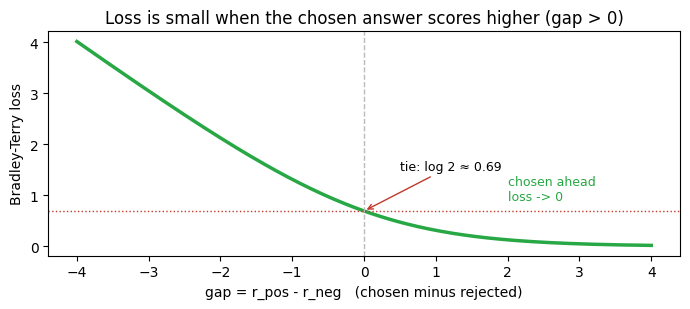

In [8]:
gaps = np.linspace(-4, 4, 200)
losses = np.log1p(np.exp(-gaps))          # softplus(-gap)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(gaps, losses, color="#28a745", lw=2.5)
ax.axvline(0, ls="--", color="#bbb", lw=1)
ax.axhline(np.log(2), ls=":", color="#c0392b", lw=1)
ax.annotate("tie: log 2 ≈ 0.69", xy=(0, np.log(2)), xytext=(0.5, 1.5), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#c0392b"))
ax.annotate("chosen ahead\nloss -> 0", xy=(3, np.log1p(np.exp(-3))), xytext=(2.0, 0.9), fontsize=9, color="#28a745")
ax.set_xlabel("gap = r_pos - r_neg   (chosen minus rejected)")
ax.set_ylabel("Bradley-Terry loss")
ax.set_title("Loss is small when the chosen answer scores higher (gap > 0)")
plt.tight_layout(); plt.show()


### Prove it — only the gap matters

The claim "order, not absolute scores" is testable. Two pairs with the **same gap of 1.0** but wildly different absolute scores give the **same loss**; and the real unit test `tests/test_bt_loss.py` confirms that *widening* the gap *lowers* the loss.


In [9]:
# Same gap (1.0), totally different scales -> identical loss.
assert abs(bt(2.0, 1.0) - bt(51.0, 50.0)) < 1e-5
print("bt(2,1) =", round(bt(2.0, 1.0), 4), " == bt(51,50) =", round(bt(51.0, 50.0), 4), " (same gap -> same loss)")

# Widening every gap lowers the loss (this is exactly tests/test_bt_loss.py).
pos_s = torch.tensor([2.0, 3.0]); neg_s = torch.tensor([1.0, 1.5])
l1 = bradley_terry_loss(pos_s,       neg_s)
l2 = bradley_terry_loss(pos_s + 1.0, neg_s)     # widen every gap by 1
assert l2 < l1
print(f"l1={l1.item():.4f}  ->  l2={l2.item():.4f}   (wider gap, smaller loss) ✓")


bt(2,1) = 0.3133  == bt(51,50) = 0.3133  (same gap -> same loss)
l1=0.2573  ->  l2=0.1029   (wider gap, smaller loss) ✓


### The stricter sibling — margin ranking

There's a stricter variant in the same file, `margin_ranking_loss`: instead of "win by any amount," it demands "win by at least `margin`" (default 1.0) and stops caring once the gap exceeds it — `max(0, margin − gap)`. Bradley-Terry keeps *gently* pushing forever; margin-ranking pushes only until the gap is clear, then relaxes. The training script picks between them with `--loss bt` (default) or `--loss margin`.


In [10]:
# Train the rookie judge from 7.2 on our single pair. Watch the gap grow.
opt = torch.optim.AdamW(judge.parameters(), lr=1e-3)
judge.train()

for step in range(1, 61):
    rp, rn = judge(pos), judge(neg)
    loss = bradley_terry_loss(rp, rn)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    if step % 10 == 0:
        gap = (rp - rn).mean().item()
        acc = (rp > rn).float().mean().item()
        print(f"step {step:2d}: loss={loss.item():.4f}  gap={gap:+.4f}  correct={acc:.0%}")

print("\nThe judge learned to score the good summary above the silly one. ✓")


step 10: loss=0.3977  gap=+0.7166  correct=100%
step 20: loss=0.0023  gap=+6.0767  correct=100%
step 30: loss=0.0002  gap=+8.4877  correct=100%
step 40: loss=0.0001  gap=+9.1239  correct=100%
step 50: loss=0.0001  gap=+9.3396  correct=100%
step 60: loss=0.0001  gap=+9.4577  correct=100%

The judge learned to score the good summary above the silly one. ✓


### Why it matters (simple → practical → deeper)

- **Simple:** if we forced the judge to hit absolute target scores, we'd be inventing numbers humans never agreed on. Comparisons are the only thing humans label reliably, so the loss uses only comparisons.
- **Practical:** one scalar judge, trained on pairs, can now score *any* answer it's never seen — including answers a future policy invents. That's the whole reason Part 8 can exist.
- **Deeper:** Bradley-Terry is the bridge from "imitate one gold answer" (Part 6) to "optimize for approval" (Parts 8–9). The judge's score is a *learned, differentiable stand-in for human preference* — and because it only constrains order, it generalizes across scales the way Elo ratings do.

**Gotcha worth knowing:** because only the gap matters, a judge can shrink the loss by inflating the gap endlessly, which is why real reward models add regularization (and why ours, on two toy pairs, will happily overfit). It's the lightest-weight idea in the part to *write* — two lines — but the single biggest conceptual lever: every downstream RL reward traces back to this gap.


---
## 7.4 Does the Judge Agree With the Humans? (Pairwise Accuracy)

```mermaid
graph LR
    pair["7.1 preference pair<br>prompt, chosen, rejected"]
    fmt["7.2 plate both<br>SFT template x2"]
    tok["7.2 tokenize<br>chosen-ids, rejected-ids"]
    score["7.2 the judge scores<br>r_pos, r_neg"]
    loss["7.3 Bradley-Terry<br>push r_pos above r_neg"]
    train["7.3 train<br>AdamW updates the judge"]
    ev["7.4 eval<br>pairwise accuracy"]

    pair --> fmt --> tok --> score --> loss --> train --> ev

    style pair fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style score fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

> **Part 6 memory:** we judged the new hire with token-F1 / exact match against the gold answer — distance from one correct string.
>
> **Part 7 now:** there's no gold string to compare against. We ask one blunt question on held-out pairs: **how often is `r_pos > r_neg`?** That fraction is *pairwise accuracy* — agreement with the human verdict.
>
> **Returns later:** in Parts 8–9 this accuracy is the trust check before we hand the judge real power — a judge that disagrees with humans would steer the policy wrong.

### What we're doing here, and why

A judge is only useful if it agrees with the people it's imitating. `eval_rm.py` does the simplest possible check: run a batch of held-out pairs through the trained reward model, count how many times the chosen answer outscores the rejected one, divide by the total. No thresholds, no calibration — just *order agreement*. 50% means coin-flip (useless); above 50% means the judge has learned something real about preference.


In [11]:
judge.eval()
with torch.no_grad():
    rp, rn = judge(pos), judge(neg)

correct = int((rp > rn).sum())
total = pos.size(0)
print(f"pairs={total}  correct (r_pos > r_neg)={correct}  accuracy={correct/total:.0%}")
print("\nThis is exactly eval_rm.py's metric:  (r_pos > r_neg).sum() / total")


pairs=1  correct (r_pos > r_neg)=1  accuracy=100%

This is exactly eval_rm.py's metric:  (r_pos > r_neg).sum() / total


**Two gotchas worth knowing:**
- **One toy pair is not a benchmark.** 100% accuracy on the single pair we overfit proves the *mechanism* works, not that the judge is wise. Real evaluation uses a held-out split of hundreds of pairs (`eval_rm.py` defaults to `val[:200]`).
- **Accuracy hides the gap size.** Two judges can both score 80% accuracy while one wins by a hair and the other by a mile. Pairwise accuracy checks *order only* — honest about what Bradley-Terry actually optimized, but blind to confidence.


---
## Closing the loop

```mermaid
graph LR
    pair["7.1 preference pair<br>prompt, chosen, rejected"]
    fmt["7.2 plate both<br>SFT template x2"]
    tok["7.2 tokenize<br>chosen-ids, rejected-ids"]
    score["7.2 the judge scores<br>r_pos, r_neg"]
    loss["7.3 Bradley-Terry<br>push r_pos above r_neg"]
    train["7.3 train<br>AdamW updates the judge"]
    ev["7.4 eval<br>pairwise accuracy"]

    pair --> fmt --> tok --> score --> loss --> train --> ev

    style pair fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style fmt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style tok fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style score fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style loss fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style train fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ev fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

**The one-sentence takeaway:** Part 7 trains a judge that reads any answer and writes one score, learned purely from "chosen beats rejected" comparisons — and because Bradley-Terry loss only cares about the *gap*, the judge just has to get the order right, never the absolute number.

### The whole judging process, in one breath

- **7.1 Gather the pairs** — every example is `(prompt, chosen, rejected)`: one question, two answers, a human verdict.
- **7.2 Score each answer** — plate both on the SFT template, read the whole thing with a bidirectional encoder, masked-mean pool, project to one scalar.
- **7.3 Push the winner up** — Bradley-Terry loss `softplus(-(r_pos − r_neg))` shrinks the gap penalty; *only the order matters* **(the one idea to remember ⭐)**.
- **7.4 Check agreement** — pairwise accuracy: how often is `r_pos > r_neg` on held-out pairs?

### You now have everything needed to read every file in `part_7/`

- [data_prefs.py](data_prefs.py) — 7.1 preference pairs `(prompt, chosen, rejected)`
- [collator_rm.py](collator_rm.py) — 7.2 plate + tokenize both answers into `(pos, neg)` ids
- [model_reward.py](model_reward.py) — 7.2 the judge: encoder → masked-mean → scalar scorecard
- [loss_reward.py](loss_reward.py) — 7.3 **Bradley-Terry & margin-ranking losses ⭐**
- [train_rm.py](train_rm.py) — 7.3 the training loop (score both → loss on the gap → AdamW)
- [eval_rm.py](eval_rm.py) — 7.4 pairwise accuracy on held-out pairs
- [orchestrator.py](orchestrator.py) — runs the tests + the tiny demo
- [tests/test_bt_loss.py](tests/test_bt_loss.py) — proves a wider gap → smaller loss
- [tests/test_reward_forward.py](tests/test_reward_forward.py) — proves the score shape `(B,)` and gradient flow

**The one-line pipeline:** `(prompt, chosen, rejected) → plate both (SFT template) → tokenize → score each (r_pos, r_neg) → Bradley-Terry on the gap → AdamW → pairwise accuracy.`

**Run the real thing** (from inside `part_7/`):

```bash
python orchestrator.py --demo
```

This runs both unit tests, then trains a tiny reward model for 300 steps and reports pairwise accuracy. The `--demo` command points at Part 4's BPE tokenizer; if you haven't run Part 4, the collator falls back to the byte tokenizer automatically — same logic, just a smaller vocab.

### What's next

Part 7 trained a judge — but the judge is still on the sidelines, scoring answers other people wrote. The real prize is putting the judge **in the driver's seat**. **Part 8 begins reinforcement learning from human feedback (PPO).** There, the Part 6 policy *generates* its own answers, this reward model *scores* them live, and a policy-gradient update nudges the policy to produce answers the judge rates higher — with a KL leash back to the SFT model so it doesn't wander into gibberish that games the score. The preference pairs, the scalar reward, and the "order is all that matters" instinct all carry straight over — only now the answers being scored are ones the model invents in the moment. **The new hire stops imitating, and starts optimizing for the judge's approval.**
